# Recreate all data figures from paper

### Import libraries

In [ ]:


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
#load infant data
infant_data = pd.read_csv('results/exp1a_infants.csv')
preschool_data = pd.read_csv('results/exp1b_preschoolers.csv')
cornet_data = pd.read_csv('results/exp2_cornet.csv')
resnet_data = pd.read_csv('results/exp2_resnet.csv')

### Plot responses to individual cues

In [3]:

def plot_cues(plot_df, color = '#4C72B0',  file_name=None):
    fig, ax = plt.subplots(figsize=(3,4))

    #color = '#4C72B0'

    sns.boxplot(
        data=plot_df, x='Condition', y='Proportion Response',
        color=color,
        linecolor='black',
        width=0.45,
        linewidth=1.5,
        flierprops=dict(marker='', alpha=0),
        boxprops=dict(alpha=1),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=0),   # removes caps
        ax=ax
    )

    sns.stripplot(
        data=plot_df, x='Condition', y='Proportion Response',
        color=color,
        size=5,
        jitter=True,
        alpha=0.7,
        linewidth=1,
        edgecolor='black',
        ax=ax
    )

    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5)

    #make y and x-axis lines thicker
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    ax.set_title('')
    ax.set_xlabel('Trial Type', fontsize=12)
    ax.set_ylabel('Proportion Response', fontsize=12)
    ax.set_ylim(-0.05, 1.02)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
    #make y-axis ticks thicker
    ax.yaxis.set_tick_params(width=1.5)

    ax.tick_params(labelsize=11)
    sns.despine()

    plt.tight_layout()
    
    if file_name is not None:
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    plt.show()

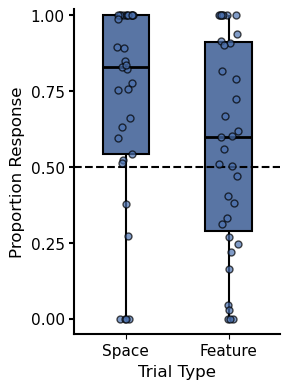

In [5]:
'''plot infant data'''

df = infant_data

plot_df = df[['B2_Space', 'B2_Feature']].melt(
    var_name='Condition', value_name='Proportion Response'
)
plot_df['Condition'] = plot_df['Condition'].map({
    'B2_Space': 'Space', 'B2_Feature': 'Feature'
})
plot_df = plot_df.dropna()

plot_cues(plot_df, color = '#4C72B0', file_name='figures/infant_cues.png')

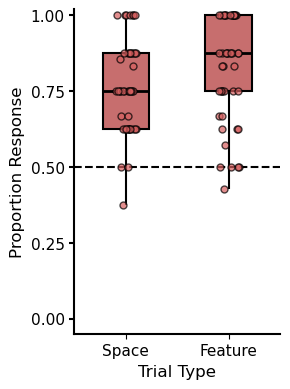

In [6]:
'''plot preschool data'''
df = preschool_data

plot_df = df[['Overall_Space', 'Overall_Feature']].melt(
    var_name='Condition', value_name='Proportion Response'
)
plot_df['Condition'] = plot_df['Condition'].map({
    'Overall_Space': 'Space', 'Overall_Feature': 'Feature'
})
plot_df = plot_df.dropna()

plot_cues(plot_df, color = "#D65F5F", file_name='figures/preschooler_cues.png')

### Plot conflict results

In [7]:

def conflict_plot(plot_df, groups = ['Infants', 'Preschoolers'], file_name=None):



    

    fig, ax = plt.subplots(figsize=(3, 4))

    colors = {groups[0]: '#4C72B0', groups[1]: "#D65F5F"}

    sns.boxplot(
        data=plot_df, x='Group', y='Proportion Response',
        palette=colors,
        linecolor='black',
        width=0.45,
        linewidth=1.5,
        flierprops=dict(marker='', alpha=0),
        boxprops=dict(alpha=1),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(linewidth=0),
        hue='Group', legend=False,
        ax=ax
    )

    sns.stripplot(
        data=plot_df, x='Group', y='Proportion Response',
        palette=colors,
        size=5,
        jitter=True,
        alpha=0.7,
        linewidth=1.5,
        edgecolor='black',
        hue='Group', legend=False,
        ax=ax
    )

    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5)

    ax.set_title('')
    ax.set_xlabel('Age Group', fontsize=12)
    #ax.set_ylabel('Proportion Response', fontsize=12)
    ax.set_ylim(-0.05, 1.02)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
    ax.tick_params(labelsize=11, color='black', width=1.5, length=5)
    sns.despine()

    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    #remove all x axis lines and labels
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([])
    ax.set_xlabel('')

    plt.tight_layout()

    if file_name is not None:
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
        
    plt.show()

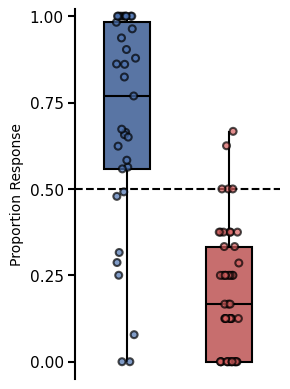

In [9]:


df1 = infant_data
df2 = preschool_data

infants = df1['B2_Conflict'].dropna().to_frame()
infants['Group'] = 'Infants'
infants = infants.rename(columns={'B2_Conflict': 'Proportion Response'})

preschoolers = df2['Overall_Conflict'].dropna().to_frame()
preschoolers['Overall_Conflict'] = 1 - preschoolers['Overall_Conflict']
preschoolers['Group'] = 'Preschoolers'
preschoolers = preschoolers.rename(columns={'Overall_Conflict': 'Proportion Response'})

plot_df = pd.concat([infants, preschoolers], ignore_index=True)
conflict_plot(plot_df, ['Infants', 'Preschoolers'], file_name='figures/infant_preschooler_conflict.png')

### Recreate all plots for models

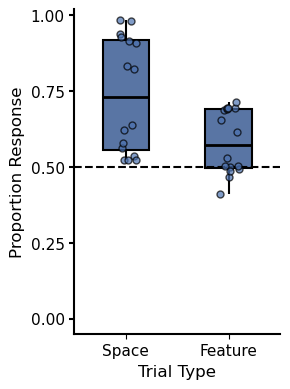

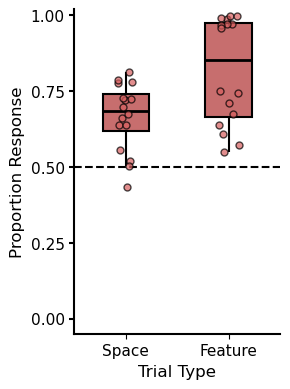

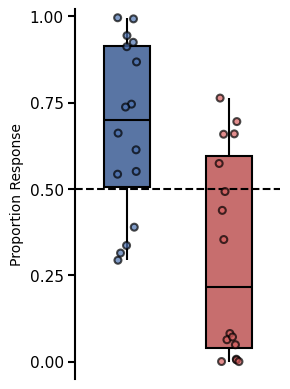

In [10]:
'''
recreate all plots with cornet
'''

model_data = cornet_data


#extract individuation model from model data
indiv_df = model_data[model_data['model_type'] == 'individuation']

indiv_df = indiv_df[['spatial', 'featural']].melt(
    var_name='Condition', value_name='Proportion Response'
)
indiv_df['Condition'] = indiv_df['Condition'].map({
    'spatial': 'Space', 'featural': 'Feature'
})

plot_cues(indiv_df, color = '#4C72B0', file_name='figures/cornet_individuation_cues.png')


'''plot identification model'''
ident_df = model_data[model_data['model_type'] == 'identification']
ident_df = ident_df[['spatial', 'featural']].melt(
    var_name='Condition', value_name='Proportion Response'
)
ident_df['Condition'] = ident_df['Condition'].map({
    'spatial': 'Space', 'featural': 'Feature'
})

plot_cues(ident_df, color = "#D65F5F", file_name='figures/cornet_classification_cues.png')


'''plot combined conflict results'''
plot_df = model_data

#reverse code the confict values
plot_df['conflict'] = 1 - plot_df['conflict']



#rename model_type to group and map values
plot_df['Group'] = plot_df['model_type'].map({
    'individuation': 'Individuation',
    'identification': 'Classification'
})

#order the model types individuation first, then classification
plot_df['Group'] = pd.Categorical(plot_df['Group'], categories=['Individuation', 'Classification'])

plot_df = plot_df[['Group', 'conflict']].dropna()
plot_df = plot_df.rename(columns={'conflict': 'Proportion Response'})
conflict_plot(plot_df, ['Individuation', 'Classification'], file_name='figures/cornet_conflict_boxplot.png')

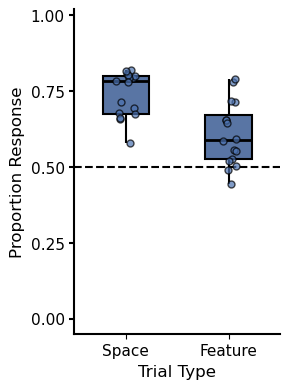

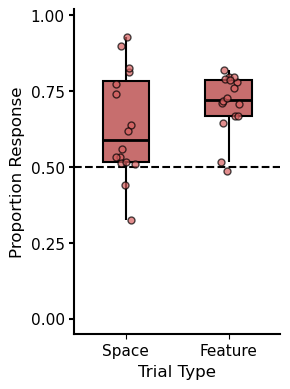

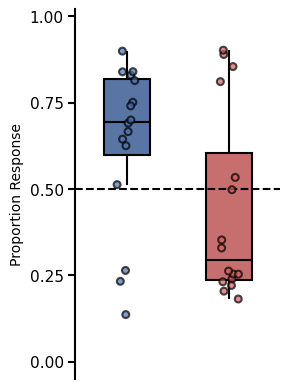

In [11]:
'''recreate all plots with resnet'''

model_data = resnet_data


#extract individuation model from model data
indiv_df = model_data[model_data['model_type'] == 'individuation']

indiv_df = indiv_df[['spatial', 'featural']].melt(
    var_name='Condition', value_name='Proportion Response'
)
indiv_df['Condition'] = indiv_df['Condition'].map({
    'spatial': 'Space', 'featural': 'Feature'
})

plot_cues(indiv_df, color = '#4C72B0', file_name='figures/resnet_individuation_cues.png')


'''plot identification model'''
ident_df = model_data[model_data['model_type'] == 'identification']
ident_df = ident_df[['spatial', 'featural']].melt(
    var_name='Condition', value_name='Proportion Response'
)
ident_df['Condition'] = ident_df['Condition'].map({
    'spatial': 'Space', 'featural': 'Feature'
})

plot_cues(ident_df, color = "#D65F5F", file_name='figures/resnet_classification_cues.png')


'''plot combined conflict results'''
plot_df = model_data

#reverse code the confict values
plot_df['conflict'] = 1 - plot_df['conflict']



#rename model_type to group and map values
plot_df['Group'] = plot_df['model_type'].map({
    'individuation': 'Individuation',
    'identification': 'Classification'
})

#order the model types individuation first, then classification
plot_df['Group'] = pd.Categorical(plot_df['Group'], categories=['Individuation', 'Classification'])

plot_df = plot_df[['Group', 'conflict']].dropna()
plot_df = plot_df.rename(columns={'conflict': 'Proportion Response'})
conflict_plot(plot_df, ['Individuation', 'Classification'], file_name='figures/resnet_conflict_boxplot.png')

#### Plot model performance on individuation and classification

In [13]:
'''Plot average performance with 95CI error bars'''

indiv_df = pd.read_csv('results/individuation_trial_performance.csv')
class_df = pd.read_csv('results/classification_trial_performance.csv')

#plot avg and 95CI for individuation and classification performance
# 
# remove column name image
indiv_df = indiv_df.drop(columns=['image'])
class_df = class_df.drop(columns=['image'])
 
#compute means for each column
indiv_means = indiv_df.mean()
class_means = class_df.mean()

#compute bootstrap 95CI for each column
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_means = []
    for _ in range(n_bootstrap):
        boot_sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(boot_sample))
    lower_bound = np.percentile(boot_means, (100 - ci) / 2)
    upper_bound = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower_bound, upper_bound

indiv_cis = {col: bootstrap_ci(indiv_df[col].dropna()) for col in indiv_df.columns}
class_cis = {col: bootstrap_ci(class_df[col].dropna()) for col in class_df.columns}


/tmp/ipykernel_2312/204131724.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_precision_df['Model'], y=class_precision_df['Accuracy'],


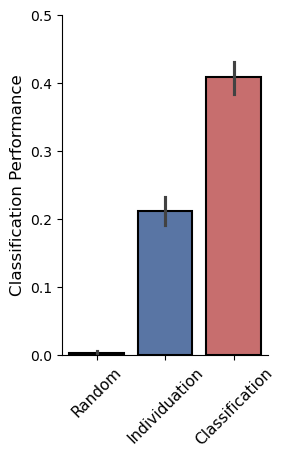

In [26]:
#plot classification performance
class_df = pd.read_csv('results/classification_trial_performance.csv')

#for classification, extract the _precision_acc columns and plot them separately and put them into a pandas dataframe
class_precision_cols = [col for col in class_df.columns if '_precision_acc' in col]
class_precision_df = class_df[class_precision_cols].melt(var_name='Model', value_name='Accuracy')
class_precision_df['Model'] = class_precision_df['Model'].str.replace('_precision_acc', '')

#rename Iden to Classification and Indiv to Individuation, random to Random in the Model column
class_precision_df['Model'] = class_precision_df['Model'].str.replace('iden', 'Classification')
class_precision_df['Model'] = class_precision_df['Model'].str.replace('idiv', 'Individuation')
class_precision_df['Model'] = class_precision_df['Model'].str.replace('random', 'Random')

#set the order of the conditions to be Random, Individuation, Classification
class_precision_df['Model'] = pd.Categorical(class_precision_df['Model'], categories=['Random', 'Individuation', 'Classification'])

#plot the means with seaborn barplot with error bars for 95CI
plt.figure(figsize=(3, 4))
sns.barplot(x=class_precision_df['Model'], y=class_precision_df['Accuracy'],
            palette=["#049D3F", '#4C72B0', "#D65F5F"], errorbar=('ci',95), edgecolor='black', linewidth=1.5)


plt.ylim(0, .5)
plt.ylabel('Classification Performance', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11)
sns.despine()
plt.tight_layout()

plt.xticks(rotation=45)
plt.savefig('figures/classification_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()



/tmp/ipykernel_2312/533247089.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indiv_acc_df['Model'], y=indiv_acc_df['Accuracy'],


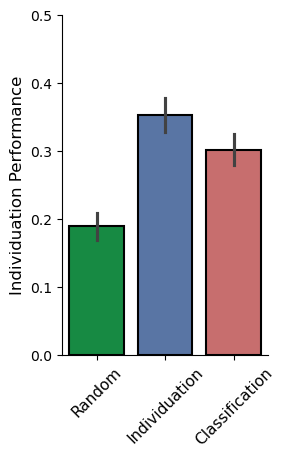

In [27]:
#plot individuation performance using the _acc columns in the individuation performance csv file
indiv_df = pd.read_csv('results/individuation_trial_performance.csv')

indiv_acc_cols = [col for col in indiv_df.columns if '_acc' in col]
indiv_acc_df = indiv_df[indiv_acc_cols].melt(var_name='Model', value_name='Accuracy')
indiv_acc_df['Model'] = indiv_acc_df['Model'].str.replace('_acc', '')

#rename Iden to Classification and Indiv to Individuation, random to Random in the Model column
indiv_acc_df['Model'] = indiv_acc_df['Model'].str.replace('iden', 'Classification')
indiv_acc_df['Model'] = indiv_acc_df['Model'].str.replace('idiv', 'Individuation')
indiv_acc_df['Model'] = indiv_acc_df['Model'].str.replace('rand', 'Random')

#set the order of the conditions to be Random, Individuation, Classification
indiv_acc_df['Model'] = pd.Categorical(indiv_acc_df['Model'], categories=['Random', 'Individuation', 'Classification'])

#plot the means with seaborn barplot with error bars for 95CI
plt.figure(figsize=(3, 4))
sns.barplot(x=indiv_acc_df['Model'], y=indiv_acc_df['Accuracy'],
            palette=["#049D3F", '#4C72B0', "#D65F5F"], errorbar=('ci',95), edgecolor='black', linewidth=1.5)
plt.ylim(0, .5)
plt.ylabel('Individuation Performance', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11)
sns.despine()
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('figures/individuation_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()



/tmp/ipykernel_1361/4047185712.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=indiv_perf, x='model', y='exact_acc', palette=["#049D3F", '#4C72B0', "#D65F5F"], edgecolor='black', linewidth=1.5)
/tmp/ipykernel_1361/4047185712.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_perf, x='model', y='corr_pred_over_all_pred', palette=["#049D3F", '#4C72B0', "#D65F5F"], edgecolor='black', linewidth=1.5)


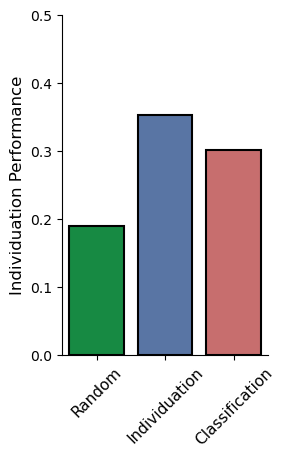

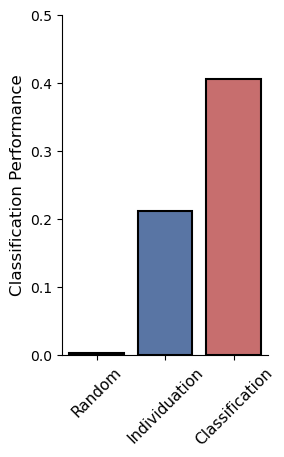

In [11]:
#load individuation and classification performance data
indiv_perf = pd.read_csv('individuation_performance.csv')
#set model order for later plotting
indiv_perf['model'] = pd.Categorical(indiv_perf['model'], categories=['Random', 'Individuation', 'Classification'])


class_perf = pd.read_csv('classification_performance.csv')
#set model order for later plotting
class_perf['model'] = pd.Categorical(class_perf['model'], categories=['Random', 'Individuation', 'Classification'])


#generate the hex for a pale green
pale_green = '#A8D08D'


#plot each as bar graphs
#plot individuation performance
plt.figure(figsize=(3, 4))
sns.barplot(data=indiv_perf, x='model', y='exact_acc', palette=["#049D3F", '#4C72B0', "#D65F5F"], edgecolor='black', linewidth=1.5)
plt.ylim(0, .5)
plt.ylabel('Individuation Performance', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11)
sns.despine()
plt.tight_layout()

plt.xticks(rotation=45)
plt.savefig('figures/individuation_performance.png', dpi=300, bbox_inches='tight')


#plot classification performance
plt.figure(figsize=(3, 4))
sns.barplot(data=class_perf, x='model', y='corr_pred_over_all_pred', palette=["#049D3F", '#4C72B0', "#D65F5F"], edgecolor='black', linewidth=1.5)
plt.ylim(0, .5)
plt.ylabel('Classification Performance', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11)
sns.despine()
plt.tight_layout()

#orient x labels vertically
plt.xticks(rotation=45)
plt.savefig('figures/classification_performance.png', dpi=300, bbox_inches='tight')



In [14]:
print(indiv_perf.columns.tolist())

['model', ' exact_acc', ' acc_within_one']
